<a href="https://colab.research.google.com/github/Ken89MathCompSci/MATNilm-master/blob/kengoh-just-add-kl-loss-only/1-March-2026-Rerun-GLC-MATNILM-with-plots-validation-metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pwd

'/content'

In [ ]:
cd MATNilm-master/

/content/MATNilm-master


In [3]:
!python main.py --epochs 80 --patience 20 --subName run20epochs

2026-03-01 05:49:04,160 - root - INFO - Using computation device: cuda:0
2026-03-01 05:49:04,161 - root - INFO - Namespace(batch=32, lr=0.001, dropout=0.1, hidden=32, logname='root', subName='run20epochs', inputLength=864, outputLength=864, debug=False, dataAug=False, prob0=0.3, prob1=0.6, prob2=0.3, prob3=0.3, epochs=80, patience=20, resume=False, checkpoint='All_best_onoff.ckpt')
2026-03-01 05:49:04,161 - root - INFO - loading data
2026-03-01 05:49:04,191 - root - INFO - loading data finished
2026-03-01 05:49:04,195 - root - INFO - Training size: 27937.
2026-03-01 05:49:04,196 - root - INFO - Initialize model
2026-03-01 05:49:04,370 - root - INFO - Model MAT
2026-03-01 05:49:05,476 - root - INFO - Training start
2026-03-01 05:49:05,476 - root - INFO - # of epoches: 0
  0% 0/874 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be 

Reading log file: /content/MATNilm-master/log/run20epochs/rootlog_2026_03_01.log
Saved plot: MAE_run80epochs.png


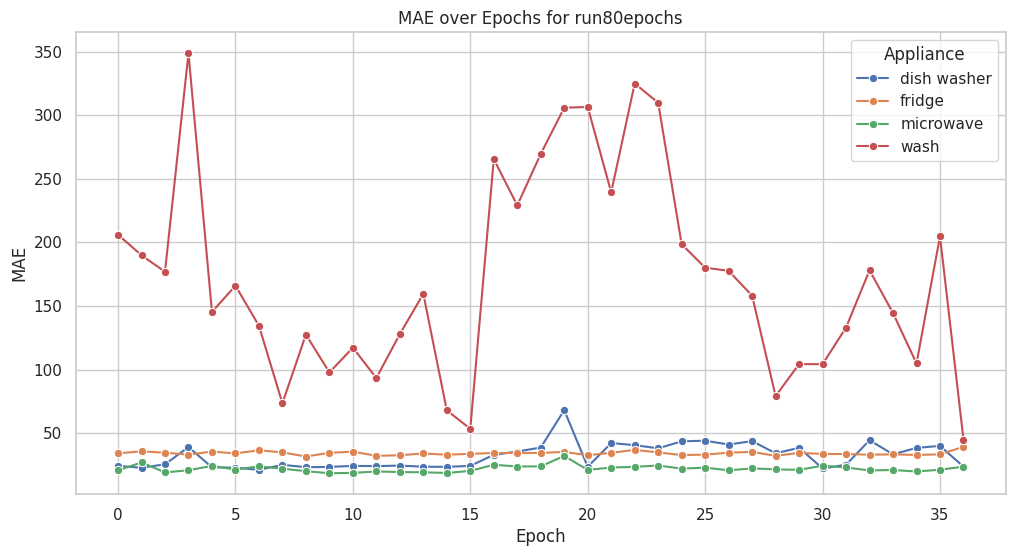

Saved plot: SAE_run80epochs.png


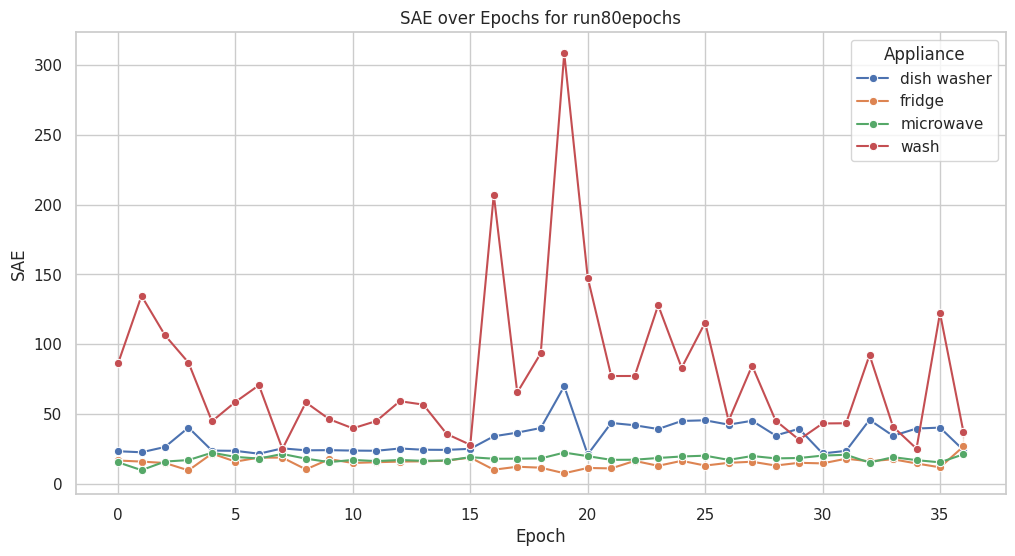

Saved plot: F1_run80epochs.png


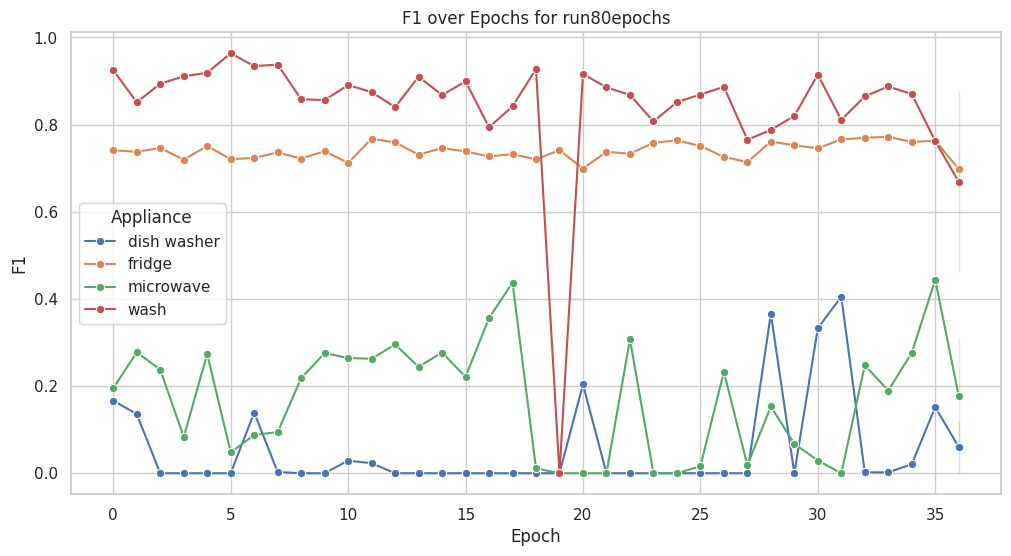

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Find the full path of the log file
log_filename = 'rootlog_2026_03_01.log'
log_path = None
for root, dirs, files in os.walk('/content/MATNilm-master'):
    if log_filename in files:
        log_path = os.path.join(root, log_filename)
        break

if log_path:
    print(f"Reading log file: {log_path}")
    with open(log_path, 'r') as f:
        log_content = f.read()

    # Use the same parsing logic as before
    data = []
    current_epoch = -1
    current_appliance = None

    lines = log_content.split('\n')
    for line in lines:
        epoch_match = re.search(r'Epoch (\d+),', line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))

        appliance_match = re.search(r'Evaluate (.+):', line)
        if appliance_match:
            current_appliance = appliance_match.group(1)

        mae_match = re.search(r'MAE: (\d+\.\d+)', line)
        sae_match = re.search(r'SAE: (\d+\.\d+)', line)
        f1_match = re.search(r'F1: (\d+\.\d+)', line)

        if current_epoch != -1 and current_appliance:
            if mae_match:
                data.append({'epoch': current_epoch, 'appliance': current_appliance, 'metric': 'MAE', 'value': float(mae_match.group(1))})
            elif sae_match:
                data.append({'epoch': current_epoch, 'appliance': current_appliance, 'metric': 'SAE', 'value': float(sae_match.group(1))})
            elif f1_match:
                data.append({'epoch': current_epoch, 'appliance': current_appliance, 'metric': 'F1', 'value': float(f1_match.group(1))})

    if data:
        df_metrics_run = pd.DataFrame(data)

        # Plotting
        sns.set_theme(style="whitegrid")
        metrics = df_metrics_run['metric'].unique()

        for metric in metrics:
            plt.figure(figsize=(12, 6))
            subset_df = df_metrics_run[df_metrics_run['metric'] == metric]
            sns.lineplot(data=subset_df, x='epoch', y='value', hue='appliance', marker='o')
            plt.title(f'{metric} over Epochs for run80epochs')
            plt.xlabel('Epoch')
            plt.ylabel(metric)
            plt.legend(title='Appliance')
            plt.grid(True)

            # Save the plot
            filename = f"{metric}_run80epochs.png"
            plt.savefig(filename)
            print(f"Saved plot: {filename}")

            plt.show()
    else:
        print("No metrics found in the log file.")
else:
    print(f"Log file {log_filename} not found.")

In [8]:
import os
import glob

# Check for recently modified files in the working directory
search_dir = '/content/MATNilm-master'
print(f"Searching in {search_dir}...")

# List all files, sorted by modification time (newest first)
files = glob.glob(os.path.join(search_dir, '*')) + glob.glob(os.path.join(search_dir, '**', '*'), recursive=True)
files.sort(key=os.path.getmtime, reverse=True)

print("Top 10 most recently modified files:")
for f in files[:10]:
    print(f"{os.path.basename(f)} - {os.path.getmtime(f)}")

Searching in /content/MATNilm-master...
Top 10 most recently modified files:
rootlog_2026_03_01.log - 1772368153.601962
checkpoint_30.ckpt - 1772364263.8806958
s0 - 1772364263.7896874
checkpoint_20.ckpt - 1772357774.4851334
All_best_onoff.ckpt - 1772355181.3263714
checkpoint_10.ckpt - 1772351287.108801
checkpoint_0.ckpt - 1772344793.642846
config.pkl - 1772344144.1955657
history_model - 1772344144.1945655
history_model - 1772344144.1945655


In [6]:
import json
import pandas as pd

# Load the results.json file
file_path = '/content/results.json'

try:
    with open(file_path, 'r') as f:
        results_data = json.load(f)

    print("Keys in results.json:", results_data.keys())

    # Inspect the 'results' key specifically
    if 'results' in results_data:
        results_content = results_data['results']
        print("\nKeys inside 'results':", results_content.keys())

        # Print a sample for the first appliance found
        first_appliance = list(results_content.keys())[0]
        print(f"\nSample structure for appliance '{first_appliance}':")
        print(results_content[first_appliance])

except Exception as e:
    print(f"Error reading file: {e}")

Keys in results.json: dict_keys(['timestamp', 'augmentation', 'epochs', 'results'])

Keys inside 'results': dict_keys(['dish washer', 'fridge', 'microwave', 'washer dryer'])

Sample structure for appliance 'dish washer':
{'standard_lnn': {'model_name': 'Standard LNN', 'num_params': 66561, 'epochs_run': 23, 'metrics': {'mae': 40.68722152709961, 'rmse': 139.86166381835938, 'nete': 0.35839951038360596, 'sae': 39.52216339111328, 'traditional_sae': 0.9317049976225631, 'precision': 0.05437075824203757, 'recall': 0.9870789109367789, 'f1': 0.10306446949985545}}, 'advanced_lnn': {'model_name': 'Advanced LNN', 'num_params': 461825, 'epochs_run': 20, 'metrics': {'mae': nan, 'rmse': nan, 'nete': nan, 'sae': nan, 'traditional_sae': 0.054230586351009746, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}}, 'attention_lnn': {'model_name': 'Attention LNN', 'num_params': 396033, 'epochs_run': 22, 'metrics': {'mae': 52.48008728027344, 'rmse': 158.3360595703125, 'nete': 1.3295652866363525, 'sae': 50.65763473510